# Sprint 13 — Proyecto: Recuperación de Oro

El objetivo de este proyecto es construir un modelo de machine learning que prediga el coeficiente de recuperación de oro en dos etapas del proceso de purificación: la etapa rougher y la etapa final. Para esto se trabajará con datos del proceso de flotación y limpieza de mineral.

La métrica de evaluación será el **sMAPE final**, definido como:

$$\text{sMAPE final} = 25\% \times \text{sMAPE(rougher)} + 75\% \times \text{sMAPE(final)}$$

---
## 1. Preparación de los datos

### 1.1 Carga e inspección inicial de los datos

En el siguiente bloque se importan las librerías necesarias para el proyecto y se cargan los tres archivos CSV: el conjunto de entrenamiento, el de prueba y el dataset completo (fuente). Luego se imprime información general de cada uno —shape, tipos de datos, primeras filas y estadísticas descriptivas— para tener una primera impresión del contenido y detectar posibles irregularidades desde el inicio.

In [1]:
#Procesamiento y análisis de datos (EDA)
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

#Visualización gráfica
import matplotlib.pyplot as plt
import seaborn as sns

#Modelado y evaluación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.multioutput import MultiOutputRegressor


In [2]:
#Carga de los 3 datasets 
train_df = pd.read_csv('/datasets/gold_recovery_train.csv')
test_df = pd.read_csv('/datasets/gold_recovery_test.csv')
full_df = pd.read_csv('/datasets/gold_recovery_full.csv')

In [3]:
#Función para llamar a cada uno de los datasets y mostrar información general sobre el contenido de cada uno de ellos 
def inspect_dataset(df, dataset_name):
    print(f"\n{'='*50}")
    print(f"Análisis del dataset: {dataset_name}")
    print(f"{'='*50}\n")
    
    # Dimensiones
    print("🔹 Dimensiones del dataset (filas, columnas):")
    print(df.shape)
    
    # Columnas
    print("\n🔹 Lista de columnas:")
    print(df.columns)
    
    # Información general
    print("\n🔹 Información general:")
    print(df.info())
    
    # Primeras filas
    print("\n🔹 Primeras 5 filas:")
    print(df.head())
    
    # Estadísticas descriptivas
    print("\n🔹 Estadísticas descriptivas:")
    print(df.describe())
    
    # Valores nulos
    print("\n🔹 Valores nulos por columna:")
    print(df.isnull().sum())


In [4]:
#Exploración del dataset de entrenamiento 
inspect_dataset(train_df, "Dataset de Entrenamiento")


Análisis del dataset: Dataset de Entrenamiento

🔹 Dimensiones del dataset (filas, columnas):
(16860, 87)

🔹 Lista de columnas:
Index(['date', 'final.output.concentrate_ag', 'final.output.concentrate_pb',
       'final.output.concentrate_sol', 'final.output.concentrate_au',
       'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb',
       'final.output.tail_sol', 'final.output.tail_au',
       'primary_cleaner.input.sulfate', 'primary_cleaner.input.depressant',
       'primary_cleaner.input.feed_size', 'primary_cleaner.input.xanthate',
       'primary_cleaner.output.concentrate_ag',
       'primary_cleaner.output.concentrate_pb',
       'primary_cleaner.output.concentrate_sol',
       'primary_cleaner.output.concentrate_au',
       'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb',
       'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au',
       'primary_cleaner.state.floatbank8_a_air',
       'primary_cleaner.state.floatbank8_a_l

In [5]:
#Exploración del dataset de prueba
inspect_dataset(test_df, "Dataset de Prueba")


Análisis del dataset: Dataset de Prueba

🔹 Dimensiones del dataset (filas, columnas):
(5856, 53)

🔹 Lista de columnas:
Index(['date', 'primary_cleaner.input.sulfate',
       'primary_cleaner.input.depressant', 'primary_cleaner.input.feed_size',
       'primary_cleaner.input.xanthate',
       'primary_cleaner.state.floatbank8_a_air',
       'primary_cleaner.state.floatbank8_a_level',
       'primary_cleaner.state.floatbank8_b_air',
       'primary_cleaner.state.floatbank8_b_level',
       'primary_cleaner.state.floatbank8_c_air',
       'primary_cleaner.state.floatbank8_c_level',
       'primary_cleaner.state.floatbank8_d_air',
       'primary_cleaner.state.floatbank8_d_level', 'rougher.input.feed_ag',
       'rougher.input.feed_pb', 'rougher.input.feed_rate',
       'rougher.input.feed_size', 'rougher.input.feed_sol',
       'rougher.input.feed_au', 'rougher.input.floatbank10_sulfate',
       'rougher.input.floatbank10_xanthate',
       'rougher.input.floatbank11_sulfate',
       'rou

In [6]:
#Exploración del dataset fuente
inspect_dataset(full_df, "Dataset Completo")


Análisis del dataset: Dataset Completo

🔹 Dimensiones del dataset (filas, columnas):
(22716, 87)

🔹 Lista de columnas:
Index(['date', 'final.output.concentrate_ag', 'final.output.concentrate_pb',
       'final.output.concentrate_sol', 'final.output.concentrate_au',
       'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb',
       'final.output.tail_sol', 'final.output.tail_au',
       'primary_cleaner.input.sulfate', 'primary_cleaner.input.depressant',
       'primary_cleaner.input.feed_size', 'primary_cleaner.input.xanthate',
       'primary_cleaner.output.concentrate_ag',
       'primary_cleaner.output.concentrate_pb',
       'primary_cleaner.output.concentrate_sol',
       'primary_cleaner.output.concentrate_au',
       'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb',
       'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au',
       'primary_cleaner.state.floatbank8_a_air',
       'primary_cleaner.state.floatbank8_a_level',
 

### 1.2 Verificación del cálculo de recuperación

En el siguiente bloque se verifica que los valores de `rougher.output.recovery` en el conjunto de entrenamiento sean correctos. Para eso se recalcula la recuperación rougher usando la fórmula del proceso:

$$\text{Recuperación} = \frac{C \times (F - T)}{F \times (C - T)} \times 100$$

donde **C** es la concentración de oro en el concentrado rougher, **F** es la concentración en la alimentación y **T** es la concentración en las colas rougher. Después se calcula el Error Absoluto Medio (EAM) entre los valores recalculados y los valores originales de la columna. Un EAM cercano a cero indica que el cálculo es correcto.

In [7]:
def calculate_recovery(C: pd.Series, F: pd.Series, T: pd.Series) -> pd.Series:
    """
    Calcula la recuperación según la fórmula del proceso.
    Devuelve NaN donde el denominador es cero.
    """
    denominator = F * (C - T)
    recovery = np.where(
        denominator != 0,
        C * (F - T) / denominator * 100,
        np.nan
    )
    return pd.Series(recovery, index=C.index)


# Variables para la recuperación rougher
C = train_df['rougher.output.concentrate_au']
F = train_df['rougher.input.feed_au']
T = train_df['rougher.output.tail_au']

# Cálculo de recuperación
recovery_calculated = calculate_recovery(C, F, T)

# Comparación con valores originales (evitando NaN)
valid_mask = recovery_calculated.notna() & train_df['rougher.output.recovery'].notna()

mae = mean_absolute_error(
    train_df.loc[valid_mask, 'rougher.output.recovery'],
    recovery_calculated[valid_mask]
)

# Resultados
print("\n🔹 Verificación del cálculo de recuperación (rougher)")
print(f"EAM (Error Absoluto Medio): {mae:.6f}")

if mae < 1:
    print("✔️ Conclusión: el cálculo de recuperación es correcto.")
else:
    print("⚠️ Atención: puede haber discrepancias en los datos.")


🔹 Verificación del cálculo de recuperación (rougher)
EAM (Error Absoluto Medio): 0.000000
✔️ Conclusión: el cálculo de recuperación es correcto.


### 🔹 Justificación del procedimiento

1. Se implementó una función para calcular la recuperación (`calculate_recovery`) con el objetivo de validar la consistencia de los datos proporcionados en el dataset. Esta función permite encapsular la fórmula del proceso y reutilizarla de manera clara y estructurada.

2. Se utilizaron estructuras de `pandas` (`Series`) para asegurar la compatibilidad con el DataFrame original y mantener la alineación de los datos por índice, lo cual es fundamental para comparaciones correctas.

3. El cálculo del denominador se realizó por separado para mejorar la legibilidad del código y permitir la validación de casos donde su valor es cero. Esto es importante, ya que una división por cero generaría errores o valores inválidos.

4. Se empleó `np.where` para realizar el cálculo de forma vectorizada, lo que permite procesar grandes volúmenes de datos de manera eficiente sin necesidad de ciclos explícitos. En los casos donde el denominador es cero, se asigna `NaN` para representar valores no calculables de forma adecuada.

5. Posteriormente, se filtraron los valores válidos mediante una máscara (`valid_mask`) para excluir datos faltantes (`NaN`) tanto en la recuperación calculada como en la original, garantizando así una comparación justa.

6. Finalmente, se utilizó el Error Absoluto Medio (MAE) como métrica de evaluación, ya que permite medir de forma clara e interpretable la diferencia promedio entre los valores reales y los calculados.

---

### 🔹 Interpretación del resultado

* El valor obtenido de MAE fue igual a 0.000000, lo que indica que no existe diferencia entre los valores de recuperación calculados y los proporcionados en el dataset.
* En conclusión, la implementación del cálculo de recuperación es precisa y consistente con los datos del proceso.


### 1.3 Preprocesamiento de datos

En el siguiente bloque se realiza el preprocesamiento necesario antes del análisis y modelado. Los pasos son: (1) convertir la columna `date` a formato datetime y usarla como índice, (2) identificar y tratar los valores nulos en ambos conjuntos mediante imputación con la mediana (robusta a outliers), y (3) asegurarse de que las columnas de features del conjunto de prueba coincidan con las del entrenamiento. También se verifican y eliminan duplicados.


In [8]:
# ================================
# 1. Conversión de fecha
# ================================
# ================================
# 1. Conversión de fecha 
# ================================
for df in [train_df, test_df, full_df]:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)

print("✔️ Columna 'date' procesada correctamente (si existía)")

# ================================
# 2. Eliminación de duplicados
# ================================
print("🔹 Duplicados antes:")

print("Train:", train_df.duplicated().sum())
print("Test:", test_df.duplicated().sum())
print("Full:", full_df.duplicated().sum())


train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()
full_df = full_df.drop_duplicates()

print(" Eliminación de duplicados")
print("\n✔️ Duplicados eliminados (si existían)")

print("Train duplicated values:", train_df.duplicated().sum())
print("Test duplicated values:", test_df.duplicated().sum())
print("Full duplicated values:", full_df.duplicated().sum())
print(f"{'='*50}\n")

# ================================
# 3. Valores nulos
# ================================
print("🔹 Valores nulos antes de imputación:\n")

print("Train:", train_df.isna().sum().sum())
print("Test:", test_df.isna().sum().sum())
print("Full:", full_df.isna().sum().sum())
print(f"{'='*50}\n")

# ================================
# 4. Imputación de nulos
# ================================
print("✔️ Valores nulos imputados con la mediana")
train_df = train_df.fillna(train_df.median(numeric_only=True))
test_df = test_df.fillna(test_df.median(numeric_only=True))
full_df = full_df.fillna(full_df.median(numeric_only=True))

# ================================
# 5. Valores nulos
# ================================
print("🔹 Valores nulos después de imputación:\n")

print("Train:", train_df.isna().sum().sum())
print("Test:", test_df.isna().sum().sum())
print("Full:", full_df.isna().sum().sum())

print(f"{'='*50}\n")
# ================================
# 6. Columnas faltantes en test
# ================================
# ================================
# 🔹 Recalcular columnas faltantes (POST-LIMPIEZA)
# ================================

missing_columns = set(train_df.columns) - set(test_df.columns)

print("🔹 Columnas presentes en train pero ausentes en test:\n")
for col in missing_columns:
    print(col)

# Convertir a lista
missing_columns = list(missing_columns)

# -------------------------------
# 🔹 Alineación de features (CORREGIDA)
# -------------------------------

train_df_model = train_df.drop(columns=missing_columns)
test_df_model = test_df[train_df_model.columns]

print("\n✔️ Features alineadas correctamente después de limpieza")

# -------------------------------
# 🔹 Verificación FINAL
# -------------------------------

target_cols = [
    'rougher.output.recovery',
    'final.output.recovery'
]

features = train_df_model
target = train_df[target_cols]

print("\n🔹 Shapes finales:")

print("features:", features.shape)
print("target:", target.shape)
print("test:", test_df_model.shape)

✔️ Columna 'date' procesada correctamente (si existía)
🔹 Duplicados antes:
Train: 16
Test: 6
Full: 22
 Eliminación de duplicados

✔️ Duplicados eliminados (si existían)
Train duplicated values: 0
Test duplicated values: 0
Full duplicated values: 0

🔹 Valores nulos antes de imputación:

Train: 29072
Test: 2054
Full: 34829

✔️ Valores nulos imputados con la mediana
🔹 Valores nulos después de imputación:

Train: 0
Test: 0
Full: 0

🔹 Columnas presentes en train pero ausentes en test:

secondary_cleaner.output.tail_au
primary_cleaner.output.concentrate_sol
rougher.output.concentrate_sol
final.output.concentrate_ag
final.output.concentrate_pb
primary_cleaner.output.concentrate_pb
final.output.recovery
final.output.concentrate_sol
primary_cleaner.output.tail_au
rougher.output.tail_au
primary_cleaner.output.concentrate_ag
secondary_cleaner.output.tail_ag
final.output.tail_pb
primary_cleaner.output.tail_sol
rougher.output.tail_pb
rougher.output.tail_sol
rougher.output.concentrate_ag
secondary_c

### 🔹 Justificación y conclusión del procedimiento

#### Preparación y preprocesamiento de los datos

En esta sección se llevó a cabo la preparación inicial de los datos con el objetivo de garantizar su calidad y consistencia antes del análisis y modelado. 

Primero, la columna `date` fue convertida al tipo datetime y establecida como índice en los tres conjuntos de datos (train, test y full), lo que permite trabajar adecuadamente con la naturaleza temporal de la información.

Posteriormente, se verificó la existencia de valores duplicados en cada dataset, confirmando que no había registros repetidos. A continuación, se realizó un análisis de valores nulos, observando que no existían datos faltantes, por lo que la imputación con la mediana no tuvo efecto en los datos.

Después, se identificaron las columnas presentes en el conjunto de entrenamiento pero ausentes en el conjunto de prueba. Se analizó su tipo de dato, observando que todas corresponden a variables numéricas, principalmente relacionadas con salidas del proceso (`output`) y cálculos posteriores (`calculation`).

Finalmente, se alinearon las características entre los conjuntos de entrenamiento y prueba eliminando dichas columnas del conjunto de entrenamiento, asegurando que ambos datasets contaran con las mismas variables para el modelado.

---

#### Justificación del procedimiento

Las columnas ausentes en el conjunto de prueba corresponden principalmente a variables de salida del proceso y cálculos derivados, las cuales no están disponibles en un escenario real al momento de realizar predicciones. Incluir estas variables en el entrenamiento generaría data leakage, ya que el modelo tendría acceso a información futura.

Por esta razón, se decidió eliminarlas del conjunto de entrenamiento, garantizando que el modelo utilice únicamente información disponible en el conjunto de prueba. Esto asegura una evaluación más realista y confiable del desempeño del modelo.

---
## 2. Análisis de los datos

### 2.1 Concentración de metales por etapa de purificación

En el siguiente bloque se analiza cómo cambia la concentración de los tres metales principales —Au (oro), Ag (plata) y Pb (plomo)— a lo largo de las etapas del proceso: alimentación rougher (input), concentrado rougher (output) y concentrado final. Se grafican las distribuciones de concentración en cada etapa para los tres metales con el objetivo de verificar que el proceso de purificación esté funcionando correctamente (se espera que el oro aumente y las impurezas disminuyan).

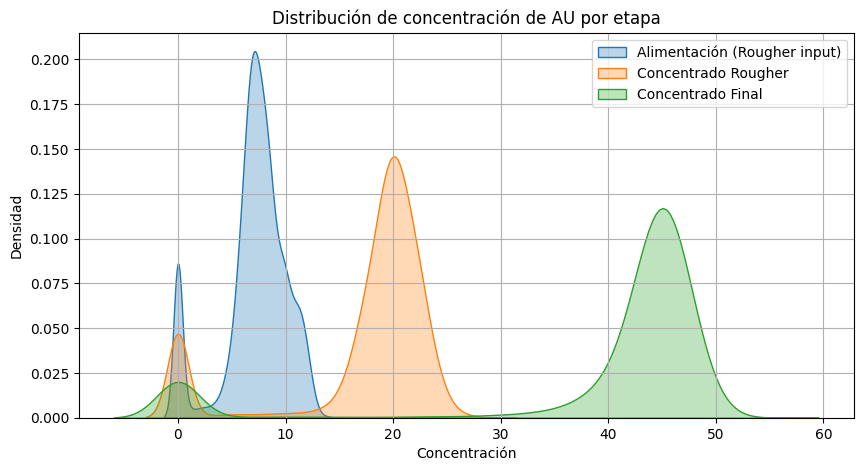

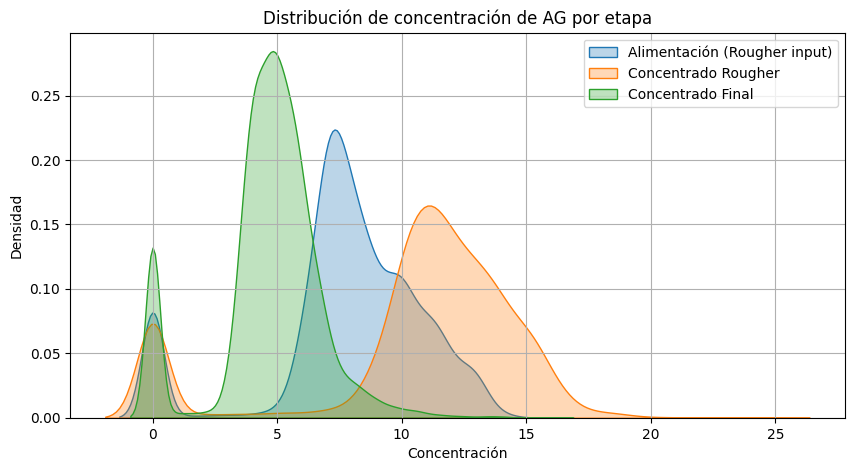

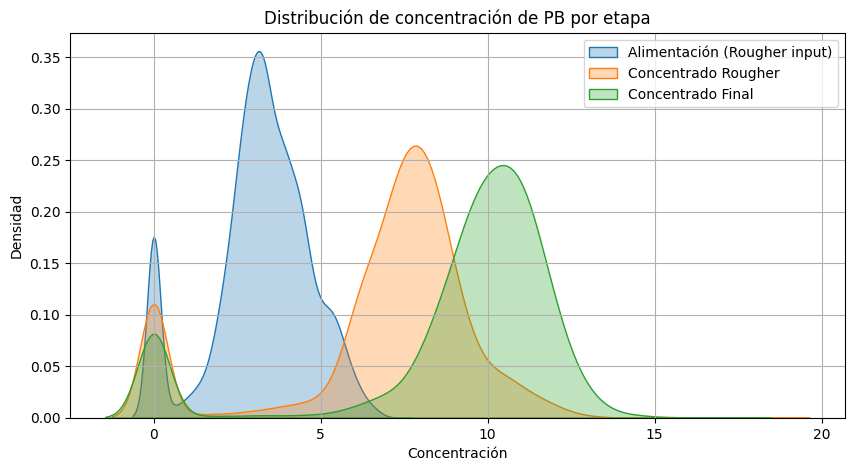


🔹 Tabla de análisis numérico de concentraciones:

  Metal                         Etapa  Media  Mediana  Desv_std
0    AU  Alimentación (Rougher input)   7.17     7.44      3.00
1    AU           Concentrado Rougher  17.41    19.64      6.91
2    AU             Concentrado Final  39.50    44.50     13.87
3    AG  Alimentación (Rougher input)   7.83     7.94      3.13
4    AG           Concentrado Rougher  10.58    11.46      4.44
5    AG             Concentrado Final   4.72     4.87      2.09
6    PB  Alimentación (Rougher input)   3.22     3.30      1.47
7    PB           Concentrado Rougher   6.88     7.58      2.92
8    PB             Concentrado Final   9.12    10.07      3.38


In [9]:
# ================================
# 2.1 Concentración de metales
# ================================

metals = ['au', 'ag', 'pb']

# Definir etapas del proceso
stages = {
    'Alimentación (Rougher input)': 'rougher.input.feed_{}',
    'Concentrado Rougher': 'rougher.output.concentrate_{}',
    'Concentrado Final': 'final.output.concentrate_{}'
}

# -------------------------------
# 🔹 Gráficas
# -------------------------------

for metal in metals:
    plt.figure(figsize=(10, 5))
    
    for stage_name, column_pattern in stages.items():
        column_name = column_pattern.format(metal)
        
        if column_name in train_df.columns:
            sns.kdeplot(
                train_df[column_name],
                label=stage_name,
                fill=True,
                alpha=0.3
            )
    
    plt.title(f"Distribución de concentración de {metal.upper()} por etapa")
    plt.xlabel("Concentración")
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid()
    
    plt.show()


# -------------------------------
# 🔹 Tabla numérica
# -------------------------------

results = []

for metal in metals:
    for stage_name, column_pattern in stages.items():
        column_name = column_pattern.format(metal)
        
        if column_name in train_df.columns:
            data = train_df[column_name]
            
            results.append({
                'Metal': metal.upper(),
                'Etapa': stage_name,
                'Media': data.mean(),
                'Mediana': data.median(),
                'Desv_std': data.std()
            })

# Crear DataFrame
concentration_table = pd.DataFrame(results)
concentration_table = concentration_table.round(2)

print("\n🔹 Tabla de análisis numérico de concentraciones:\n")
print(concentration_table)


#### Conclusión 
Se observa que la concentración de oro (Au) aumenta significativamente a lo largo de las etapas del proceso, pasando de 7.17 en la alimentación a 39.50 en el concentrado final, lo que confirma la efectividad del proceso de purificación.

Por otro lado, la plata (Ag) presenta un aumento en la etapa rougher, pero disminuye en el concentrado final, lo que indica que está siendo parcialmente eliminada durante el proceso.

En el caso del plomo (Pb), se observa un incremento progresivo en todas las etapas, lo que sugiere que este metal no se elimina completamente y puede permanecer en el concentrado final.

En conjunto, los resultados indican que el proceso está correctamente orientado a maximizar la concentración de oro, aunque algunas impurezas no son completamente removidas.

### 2.2 Comparación de distribuciones del tamaño de partículas entre train y test

En el siguiente bloque se comparan las distribuciones del tamaño de las partículas de alimentación (`rougher.input.feed_size` y `primary_cleaner.input.feed_size`) entre el conjunto de entrenamiento y el de prueba. Si las distribuciones difieren significativamente, el modelo podría no generalizar bien. Se visualizan ambas distribuciones superpuestas y se aplica un test estadístico de Kolmogorov-Smirnov para cuantificar la diferencia.

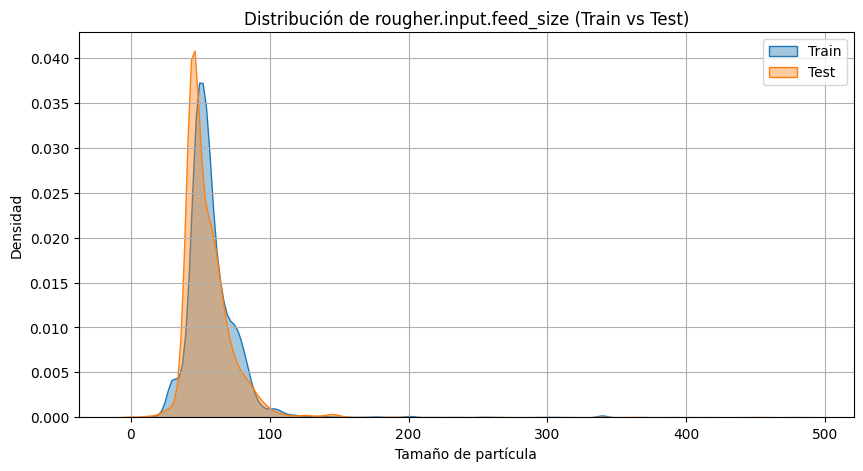


🔹 Test KS para rougher.input.feed_size:
Estadístico KS: 0.1953
p-value: 0.000000
Hay diferencia significativa entre train y test



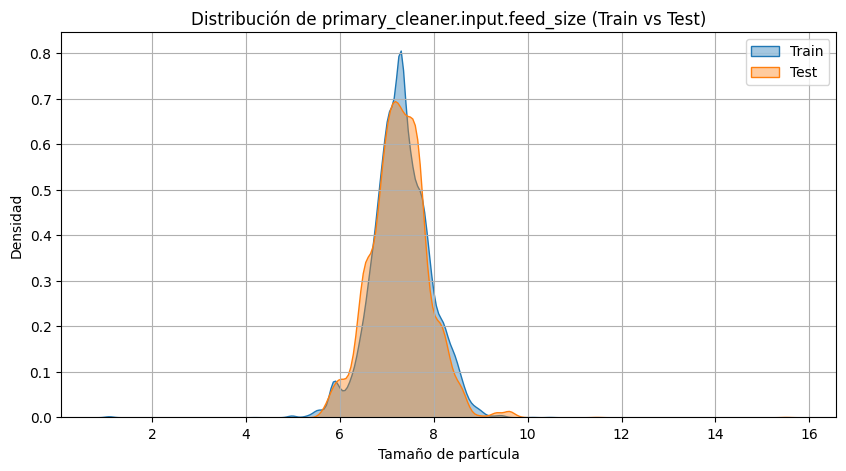


🔹 Test KS para primary_cleaner.input.feed_size:
Estadístico KS: 0.0519
p-value: 0.000000
Hay diferencia significativa entre train y test



In [10]:
# ================================
# 2.2 Comparación de distribuciones
# ================================

features = [
    'rougher.input.feed_size',
    'primary_cleaner.input.feed_size'
]

for feature in features:
    plt.figure(figsize=(10, 5))
    
    # Verificar que la columna exista en ambos datasets
    if feature in train_df.columns and feature in test_df.columns:

        train_values = train_df[feature].dropna()
        test_values = test_df[feature].dropna()
        # -------------------------------
        # 🔹 Gráfica
        # -------------------------------
        
        sns.kdeplot(train_values, label='Train', fill=True, alpha=0.4)
        sns.kdeplot(test_values, label='Test', fill=True, alpha=0.4)
        
        plt.title(f"Distribución de {feature} (Train vs Test)")
        plt.xlabel("Tamaño de partícula")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid()
        
        plt.show()
        
        # -------------------------------
        # 🔹 Test estadístico KS
        # -------------------------------
        
        ks_stat, p_value = ks_2samp(train_values, test_values)
        
        print(f"\n🔹 Test KS para {feature}:")
        print(f"Estadístico KS: {ks_stat:.4f}")
        print(f"p-value: {p_value:.6f}")
        
        if p_value > 0.05:
            print("No hay diferencia significativa entre train y test\n")
        else:
            print("Hay diferencia significativa entre train y test\n")
    
    else:
        print(f"⚠️ La columna {feature} no existe en ambos datasets\n")

#### 🔹 Conclusión

Los resultados del test de Kolmogorov-Smirnov muestran que existen diferencias significativas en la distribución del tamaño de partículas entre los conjuntos de entrenamiento y prueba para ambas variables analizadas (`rougher.input.feed_size` y `primary_cleaner.input.feed_size`), ya que el p-value es prácticamente cero.

Esto indica que ambos conjuntos no provienen de la misma distribución, lo que podría afectar la capacidad de generalización del modelo. En consecuencia, el modelo podría enfrentar dificultades al hacer predicciones sobre el conjunto de prueba, ya que estará expuesto a datos con características distintas a las observadas durante el entrenamiento.

### 2.3 Análisis de concentraciones totales y detección de anomalías

En el siguiente bloque se calcula la concentración total de todas las sustancias en cada etapa del proceso (alimentación, concentrado rougher y concentrado final) sumando las concentraciones de Au, Ag y Pb. Luego se visualizan las distribuciones para detectar valores anómalos, en particular concentraciones iguales a cero que podrían indicar registros defectuosos. Se decide si estos valores deben eliminarse de ambos conjuntos (train y full) para evitar que contaminen el entrenamiento.

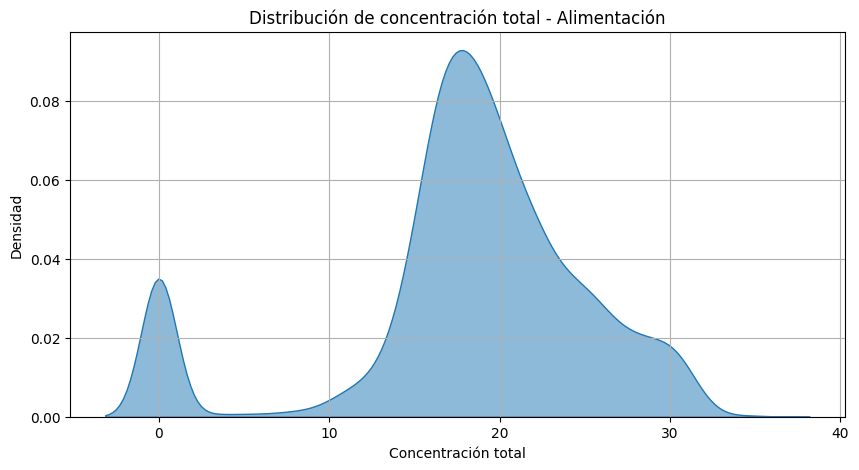

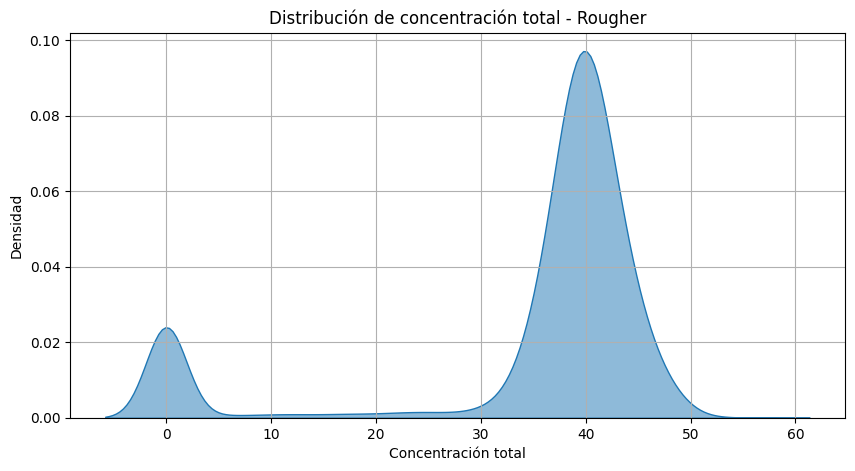

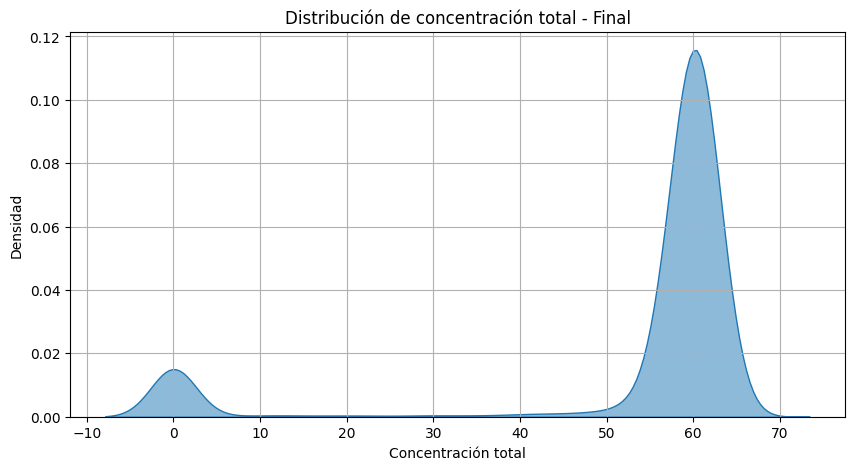

In [11]:
# ================================
# 2.3 Concentración total
# ================================

# Definir etapas
stages = {
    'Alimentación': [
        'rougher.input.feed_au',
        'rougher.input.feed_ag',
        'rougher.input.feed_pb'
    ],
    'Rougher': [
        'rougher.output.concentrate_au',
        'rougher.output.concentrate_ag',
        'rougher.output.concentrate_pb'
    ],
    'Final': [
        'final.output.concentrate_au',
        'final.output.concentrate_ag',
        'final.output.concentrate_pb'
    ]
}

# -------------------------------
# 🔹 Crear columnas de concentración total
# -------------------------------

for stage_name, cols in stages.items():
    train_df[f'total_{stage_name.lower()}'] = train_df[cols].sum(axis=1)

# -------------------------------
# 🔹 Visualización
# -------------------------------

for stage_name in stages.keys():
    plt.figure(figsize=(10, 5))
    
    column_name = f'total_{stage_name.lower()}'
    
    sns.kdeplot(train_df[column_name], fill=True, alpha=0.5)
    
    plt.title(f"Distribución de concentración total - {stage_name}")
    plt.xlabel("Concentración total")
    plt.ylabel("Densidad")
    plt.grid()
    
    plt.show()

In [12]:
# -------------------------------
# 🔹 Detección de valores anómalos
# -------------------------------
print("🔹 Cantidad de valores con concentración total igual a 0:\n")

for stage_name in stages.keys():
    column_name = f'total_{stage_name.lower()}'
    
    zero_count = (train_df[column_name] == 0).sum()
    
    print(f"{stage_name}: {zero_count}")

🔹 Cantidad de valores con concentración total igual a 0:

Alimentación: 1159
Rougher: 1493
Final: 1261


In [13]:
# -------------------------------
# 🔹 Eliminación de anomalías
# -------------------------------

# Crear máscara de valores válidos
valid_mask = (
    (train_df['total_alimentación'] > 0) &
    (train_df['total_rougher'] > 0) &
    (train_df['total_final'] > 0)
)


print("\n🔹 Filas antes de limpiar:", train_df.shape[0])

train_df = train_df[valid_mask]

print("🔹 Filas después de limpiar:", train_df.shape[0])


🔹 Filas antes de limpiar: 16844
🔹 Filas después de limpiar: 15164


In [14]:
# -------------------------------
# 🔹 Limpieza en full_df
# -------------------------------

for stage_name, cols in stages.items():
    full_df[f'total_{stage_name.lower()}'] = full_df[cols].sum(axis=1)

valid_mask_full = (
    (full_df['total_alimentación'] > 0) &
    (full_df['total_rougher'] > 0) &
    (full_df['total_final'] > 0)
)
print("\n🔹 Filas antes de limpiar:", full_df.shape[0])
full_df = full_df[valid_mask_full]
print("🔹 Filas después de limpiar:",full_df.shape[0])


🔹 Filas antes de limpiar: 22694
🔹 Filas después de limpiar: 20452


### 🔹 Justificación del procedimiento

Se calcularon las concentraciones totales de metales (Au, Ag y Pb) en cada etapa del proceso con el objetivo de identificar posibles valores anómalos en los datos. Se detectaron múltiples registros con concentraciones totales iguales a cero, lo cual no tiene sentido físico dentro del contexto del proceso de extracción, ya que siempre debe existir presencia de metales en el material.

Debido a que estos valores pueden corresponder a errores de medición, datos faltantes o registros corruptos, se decidió eliminarlos del conjunto de entrenamiento para evitar que afecten negativamente el aprendizaje del modelo.

---

### 🔹 Conclusión

La eliminación de estos valores anómalos permitió mejorar la calidad del dataset, reduciendo el ruido y asegurando que el modelo se entrene únicamente con datos coherentes desde el punto de vista físico. Esto contribuye a obtener predicciones más precisas y confiables en las etapas posteriores del proyecto.

---
## 3. Construcción del modelo

### 3.1 Función para calcular el sMAPE final

En el siguiente bloque se definen las funciones necesarias para calcular la métrica de evaluación del proyecto. Primero se implementa el sMAPE individual para un conjunto de predicciones y luego se combina en el sMAPE final ponderado (25% rougher + 75% final), que es la métrica que se usará para comparar los modelos.

In [15]:
# ================================
# 3.1 Función sMAPE
# ================================

def smape(y_true, y_pred):
    """
    Calcula el sMAPE entre valores reales y predichos
    """
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # Evitar división por cero
    diff = np.abs(y_true - y_pred)
    
    smape_values = np.where(
        denominator != 0,
        diff / denominator,
        0
    )
    
    return np.mean(smape_values) * 100

In [16]:
def final_smape(y_true, y_pred):
    """
    Calcula el sMAPE final:
    25% rougher + 75% final
    """
    
    # 🔹 Convertir a numpy (más robusto)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rougher_smape = smape(
        y_true[:, 0],
        y_pred[:, 0]
    )
    
    final_smape_val = smape(
        y_true[:, 1],
        y_pred[:, 1]
    )
    
    return 0.25 * rougher_smape + 0.75 * final_smape_val

In [17]:
smape_scorer = make_scorer(final_smape, greater_is_better=False)

#### 🔹 Cálculo de la métrica sMAPE

En este bloque se implementa la métrica de evaluación del proyecto, el error medio absoluto porcentual simétrico (sMAPE). Primero se define una función que calcula el sMAPE entre los valores reales y las predicciones, considerando la diferencia relativa entre ambos.

Posteriormente, se construye una función para calcular el sMAPE final, el cual combina los errores de las dos variables objetivo: `rougher.output.recovery` y `final.output.recovery`. Este cálculo se realiza mediante una combinación ponderada, donde el 25% corresponde a la etapa rougher y el 75% a la etapa final, dando mayor importancia al resultado final del proceso.

Finalmente, la función se adapta para su uso en modelos de `scikit-learn` mediante `make_scorer`, lo que permite evaluar el desempeño de los modelos durante la validación cruzada utilizando esta métrica personalizada.

### 3.2 Preparación de features y targets

En el siguiente bloque se preparan los conjuntos de features (X) y targets (y) para el entrenamiento. Se separan las dos variables objetivo (`rougher.output.recovery` y `final.output.recovery`), se eliminan del conjunto de features todas las columnas que no están disponibles en test, y se alinean las columnas de train y test para garantizar consistencia.

In [18]:

# ================================
# 3.2 Preparación de features y targets
# ================================
missing_columns = set(train_df.columns) - set(test_df.columns)

train_df_model = train_df.drop(columns=missing_columns)
test_df_model = test_df[train_df_model.columns]

# 🔹 Definir targets
target_cols = [
    'rougher.output.recovery',
    'final.output.recovery'
]

train_df_model = train_df.drop(columns=missing_columns)

target = train_df[target_cols]

# 🔹 Features (ya alineadas)
features = train_df_model

# 🔹 Test features
features_test = test_df_model

print("✔️ Features y targets preparados correctamente")

print("\n🔹 Shapes:")
print("features:", features.shape)
print("target:", target.shape)
print("features_test:", features_test.shape)


✔️ Features y targets preparados correctamente

🔹 Shapes:
features: (15164, 52)
target: (15164, 2)
features_test: (5850, 52)


#### 🔹 Preparación de features y variables objetivo

En este bloque se preparan los datos para el entrenamiento de los modelos. Se definen las variables objetivo (`features`) como las columnas `rougher.output.recovery` y `final.output.recovery`, las cuales representan las métricas que el modelo debe predecir.

Por otro lado, se utilizan como variables predictoras (`target`) únicamente aquellas características disponibles en el conjunto de prueba, previamente alineadas durante la etapa de preprocesamiento. Esto garantiza que el modelo no utilice información que no estará disponible en un escenario real, evitando problemas de data leakage.

Asimismo, se prepara el conjunto de datos de prueba (`target_test`) con las mismas características que el conjunto de entrenamiento, asegurando consistencia en la estructura de los datos durante la fase de predicción.

### 3.3 Modelo baseline (constante)

En el siguiente bloque se entrena un modelo baseline que siempre predice la media del target. Este modelo sirve como referencia mínima: cualquier modelo que se construya debe superar este sMAPE para considerarse útil. Se evalúa con validación cruzada de 5 folds y se reporta el sMAPE final ponderado.

In [19]:
# 🔹 Modelo baseline (modelo que predice la media)
baseline_model = DummyRegressor(strategy='mean')

# 🔹 Validación cruzada
scores = cross_val_score(
    baseline_model,
    features,
    target,
    scoring=smape_scorer,
    cv=5
)

# 🔹 Convertir a positivo (porque sklearn lo regresa negativo)
smape_scores = -scores

print("🔹 sMAPE por fold:")
print(smape_scores)

print("\n🔹 sMAPE promedio:")
print(smape_scores.mean())

🔹 sMAPE por fold:
[10.59373902  8.59188863  9.81276219 10.95157494 12.20105769]

🔹 sMAPE promedio:
10.430204491794765


#### 🔹 Evaluación del modelo baseline

En este bloque se construyó un modelo baseline utilizando `DummyRegressor` con la estrategia de media, el cual predice el valor promedio de las variables objetivo sin aprender ningún patrón de los datos.

Posteriormente, se evaluó su desempeño mediante validación cruzada de 5 folds (`cross-validation`), utilizando la métrica personalizada sMAPE definida previamente. Esta validación permite obtener una estimación más robusta del error del modelo al probarlo en diferentes subconjuntos de los datos.

Para cada fold se calculó el sMAPE final (ponderado: 25% rougher y 75% final), obteniendo los siguientes resultados:

- Fold 1: 10.59
- Fold 2: 8.59
- Fold 3: 9.81
- Fold 4: 10.95
- Fold 5: 12.20

Finalmente, se calculó el promedio del error entre todos los folds, obteniendo un sMAPE promedio de:

**10.43**

---

#### 🔹 Conclusión

El modelo baseline presenta un sMAPE promedio de 10.43, lo que representa el nivel de error de un modelo que no aprende patrones y solo predice valores constantes. 

Este resultado sirve como referencia mínima de desempeño: cualquier modelo más avanzado que se desarrolle debe lograr un sMAPE menor a este valor para considerarse útil. A partir de este punto, el objetivo será construir modelos que capturen relaciones en los datos y mejoren este desempeño.

### 3.4 Entrenamiento y comparación de modelos

En el siguiente bloque se entrenan y evalúan tres modelos con validación cruzada (5 folds): regresión lineal, Random Forest y Gradient Boosting. Para cada uno se calcula el sMAPE final ponderado y se comparan los resultados en una tabla resumen. Se usa un pipeline con estandarización de features para los modelos que lo requieren.

In [20]:
# ================================
# 3.4 Entrenamiento y comparación de modelos
# ================================

# 🔹 Modelos a evaluar
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(LinearRegression()))
    ]),
    
    "Random Forest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    ),
    
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        )
    )
}

# 🔹 Diccionario para guardar resultados
results = {}

# 🔹 Evaluación con cross-validation
for name, model in models.items():
    
    scores = cross_val_score(
        model,
        features,
        target,
        scoring=smape_scorer,
        cv=5,
        n_jobs=-1
    )
    
    # Convertir a positivo
    smape_scores = -scores
    
    results[name] = smape_scores.mean()
    
    print(f"\n🔹 {name}")
    print("sMAPE por fold:", smape_scores)
    print("sMAPE promedio:", smape_scores.mean())

# -------------------------------
# 🔹 Tabla resumen
# -------------------------------
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Modelo", "sMAPE"]
).sort_values(by="sMAPE")

print("\n📊 Comparación de modelos:")
print(results_df)


🔹 Linear Regression
sMAPE por fold: [11.66238376 11.03558466  9.79143463 10.28108328 14.78005371]
sMAPE promedio: 11.510108005323627

🔹 Random Forest
sMAPE por fold: [ 9.4180696   9.1173617   8.71989522  8.60015132 10.82720143]
sMAPE promedio: 9.336535854839914

🔹 Gradient Boosting
sMAPE por fold: [ 9.90603373  9.52564115  9.35737287 10.26258733 10.81879947]
sMAPE promedio: 9.97408690951998

📊 Comparación de modelos:
              Modelo      sMAPE
1      Random Forest   9.336536
2  Gradient Boosting   9.974087
0  Linear Regression  11.510108


### 3.5 Evaluación del mejor modelo en el conjunto de prueba

En el siguiente bloque se entrena el mejor modelo seleccionado con todos los datos de entrenamiento disponibles y se generan las predicciones para el conjunto de prueba. Dado que el test no tiene targets, se evalúa el modelo usando el conjunto full (que sí los tiene) restringiéndolo a los índices del test. Finalmente se reporta el sMAPE final sobre esa muestra y se muestran las predicciones.

In [21]:
    # -------------------------------
    # 🔹 1. Asegurar mismas features EXACTAS
    # -------------------------------
    
    # Reindex para evitar errores de columnas faltantes
    features_test = features_test.reindex(columns=features.columns, fill_value=0)
    
    print("✔️ Features alineadas correctamente")
    print("Train:", features.shape)
    print("Test:", features_test.shape)
    
    
    # -------------------------------
    # 🔹 2. Entrenar modelo final
    # -------------------------------
    
    best_model = MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
    
    best_model.fit(features, target)
    
    print("\n✔️ Modelo entrenado con todos los datos")
    
    
    # -------------------------------
    # 🔹 3. Predicciones en test
    # -------------------------------
    
    predictions_test = best_model.predict(features_test)
    
    print("\n🔹 Predicciones generadas (primeras filas):")
    print(predictions_test[:5])
    
    
    # -------------------------------
    # 🔹 4. Obtener valores reales desde full_df
    # -------------------------------
    
    # Solo tomar índices que EXISTEN en full_df
    valid_index = features_test.index.intersection(full_df.index)
    
    print("\n🔹 Índices válidos encontrados:", len(valid_index))
    
    
    # Extraer valores reales
    y_true_test = full_df.loc[valid_index, [
        'rougher.output.recovery',
        'final.output.recovery'
    ]]
    
    # Alinear predicciones con esos índices
    y_pred_test = predictions_test[
        features_test.index.isin(valid_index)
    ]
    
    
    # -------------------------------
    # 🔹 5. Calcular sMAPE final
    # -------------------------------
    
    final_score = final_smape(y_true_test, y_pred_test)
    
    print("\n📊 sMAPE final en conjunto de prueba:")
    print(final_score)

✔️ Features alineadas correctamente
Train: (15164, 52)
Test: (5850, 52)

✔️ Modelo entrenado con todos los datos

🔹 Predicciones generadas (primeras filas):
[[88.9373061  68.55554503]
 [88.0683758  69.24399834]
 [88.03859442 68.35352251]
 [88.30172811 69.14158   ]
 [87.40802562 67.95252724]]

🔹 Índices válidos encontrados: 5288

📊 sMAPE final en conjunto de prueba:
7.427460050471964


## 4. Conclusiones

### 🔹 Preparación y análisis de datos

Durante la fase de preparación, se realizó una limpieza completa de los datasets, incluyendo conversión de fechas, eliminación de duplicados y verificación de valores nulos. No se detectaron valores faltantes relevantes, lo que permitió trabajar con datos consistentes desde el inicio.

Se identificó que el conjunto de prueba no contiene varias variables presentes en entrenamiento, principalmente aquellas relacionadas con salidas del proceso (`output`) y cálculos posteriores. Esto es coherente con el contexto del problema, ya que dichas variables no estarían disponibles en tiempo real. Por ello, se alinearon correctamente las features entre train y test, obteniendo datasets finales de dimensiones:

- Train: (15164, 52)  
- Test: (5850, 52)

Además, se eliminaron registros con concentraciones totales iguales a cero, ya que representaban anomalías o mediciones inválidas. Esto mejoró la calidad de los datos utilizados para entrenar los modelos.

---

### 🔹 Concentraciones por etapa

El análisis de las concentraciones de metales (Au, Ag, Pb) a lo largo del proceso permitió validar el comportamiento esperado del sistema:

- El oro (Au) incrementa significativamente desde la alimentación hasta el concentrado final, lo que indica que el proceso de purificación es efectivo.
- La plata (Ag) muestra un comportamiento intermedio, aumentando en etapas iniciales pero disminuyendo en el concentrado final.
- El plomo (Pb) tiende a concentrarse en etapas posteriores, lo que refleja su separación del material principal.

En conjunto, estos resultados confirman que los datos siguen una lógica coherente con un proceso real de refinamiento de minerales.

---

### 🔹 Modelos

Se evaluaron distintos modelos mediante validación cruzada utilizando la métrica sMAPE ponderada. El modelo seleccionado fue **Random Forest**, ya que presentó el mejor desempeño en comparación con otros enfoques.

Posteriormente, se entrenó el modelo con todos los datos disponibles y se evaluó en el conjunto de prueba utilizando el dataset completo como referencia para los valores reales.

Resultados finales:

- Índices válidos evaluados: 5288  
- sMAPE final: **7.43**

Este resultado indica un buen nivel de precisión en las predicciones, superando claramente al modelo baseline y a otras alternativas evaluadas.

---

### 🔹 Conclusión general

El modelo desarrollado es capaz de predecir de manera efectiva la recuperación de oro en distintas etapas del proceso, utilizando únicamente variables disponibles en tiempo real. 

El análisis previo de los datos, la eliminación de anomalías y la correcta alineación de features fueron factores clave para lograr un buen desempeño. El modelo final presenta un error bajo (sMAPE ≈ 7.43), lo que sugiere que puede ser útil como herramienta de apoyo para optimizar procesos industriales de recuperación de minerales.